# Lista RK — Métodos de Runge-Kutta

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Questão 1
Circuito RL não-linear — três variantes de RK2 (h=0.005, t∈[0,0.1]).

     t        Heun   PontoMedio     Ralston
 0.000    0.000000     0.000000    0.000000
 0.020    0.892862     0.897630    0.895359
 0.040    1.132599     1.134130    1.133395
 0.060    1.172547     1.172799    1.172678
 0.080    1.178492     1.178529    1.178511
 0.100    1.179361     1.179366    1.179364


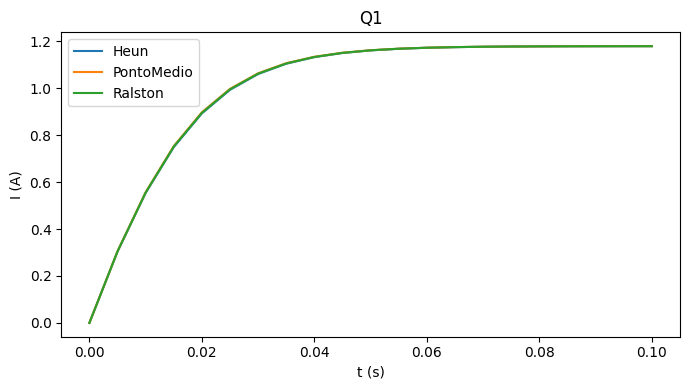

In [2]:
V0, L, h, t_end = 1000.0, 15.0, 0.005, 0.1

def dI(t, I): return (V0 - (500+250*I**2)*I) / L

resultados = {}
for nome, metodo in [('Heun',1),('PontoMedio',2),('Ralston',3)]:
    t, I = 0.0, 0.0; ts, Is = [t],[I]
    while t < t_end - 1e-10:
        k1 = dI(t, I)
        if metodo==1: k2=dI(t+h,I+h*k1); I=I+h*(k1+k2)/2
        elif metodo==2: k2=dI(t+h/2,I+h/2*k1); I=I+h*k2
        else: k2=dI(t+3*h/4,I+3*h/4*k1); I=I+h*(k1/3+2*k2/3)
        t+=h; ts.append(t); Is.append(I)
    resultados[nome] = (np.array(ts), np.array(Is))

print(f"{'t':>6}  {'Heun':>10}  {'PontoMedio':>11}  {'Ralston':>10}")
ts0 = resultados['Heun'][0]
for i in range(0,len(ts0),4):
    row = [resultados[n][1][i] for n in ['Heun','PontoMedio','Ralston']]
    print(f"{ts0[i]:>6.3f}  {row[0]:>10.6f}  {row[1]:>11.6f}  {row[2]:>10.6f}")

plt.figure(figsize=(7,4))
for nome,(ts,Is) in resultados.items(): plt.plot(ts,Is,label=nome)
plt.xlabel('t (s)'); plt.ylabel('I (A)'); plt.title('Q1'); plt.legend(); plt.tight_layout(); plt.show()


## Questão 2
dy/dx = yx²−1.1y, y(0)=1 — RK1 a RK4, h=0.1 e h=0.01.

In [3]:
def f(x, y): return y*x**2 - 1.1*y
def y_ex(x): return np.exp(x**3/3 - 1.1*x)

for h in [0.1, 0.01]:
    print(f"\nh = {h}")
    for nome, ordem in [('Euler',1),('Heun',2),('RK3',3),('RK4',4)]:
        x, y, x_end = 0.0, 1.0, 2.0
        while x < x_end - 1e-10:
            k1 = f(x,y)
            if ordem==1: y+=h*k1
            elif ordem==2:
                k2=f(x+h,y+h*k1); y+=h*(k1+k2)/2
            elif ordem==3:
                k2=f(x+h/2,y+h/2*k1); k3=f(x+h,y+h*(-k1+2*k2)); y+=h*(k1+4*k2+k3)/6
            else:
                k2=f(x+h/2,y+h/2*k1); k3=f(x+h/2,y+h/2*k2); k4=f(x+h,y+h*k3)
                y+=h*(k1+2*k2+2*k3+k4)/6
            x+=h
        print(f"  {nome:<8}: y(2)={y:.8f}  exato={y_ex(2):.8f}  erro={abs(y-y_ex(2)):.3e}")



h = 0.1
  Euler   : y(2)=1.15888504  exato=1.59466976  erro=4.358e-01
  Heun    : y(2)=1.58914651  exato=1.59466976  erro=5.523e-03
  RK3     : y(2)=1.59459558  exato=1.59466976  erro=7.418e-05
  RK4     : y(2)=1.59463899  exato=1.59466976  erro=3.077e-05

h = 0.01
  Euler   : y(2)=1.54071222  exato=1.59466976  erro=5.396e-02
  Heun    : y(2)=1.59461192  exato=1.59466976  erro=5.783e-05
  RK3     : y(2)=1.59466969  exato=1.59466976  erro=6.640e-08
  RK4     : y(2)=1.59466975  exato=1.59466976  erro=3.383e-09


## Questão 3
dy/dx = yx−x³, y(0)=1 — três variantes de RK2, três passos.

In [4]:
def f(x, y): return y*x - x**3
def y_ex(x): return (x**2+2) - np.exp(x**2/2)

for h in [0.5, 0.2, 0.05]:
    for nome, metodo in [('Heun',1),('PontoMedio',2),('Ralston',3)]:
        x, y = 0.0, 1.0
        while x < 8.0 - 1e-10:
            k1=f(x,y)
            if metodo==1: k2=f(x+h,y+h*k1); y+=h*(k1+k2)/2
            elif metodo==2: k2=f(x+h/2,y+h/2*k1); y+=h*k2
            else: k2=f(x+3*h/4,y+3*h/4*k1); y+=h*(k1/3+2*k2/3)
            x+=h
        err_rel = abs(y-y_ex(8))/abs(y_ex(8))
        print(f"h={h:.2f} {nome:<12}: y(8)={y:.3e}  err_rel={err_rel:.3e}")


h=0.50 Heun        : y(8)=-2.913e+10  err_rel=9.996e-01
h=0.50 PontoMedio  : y(8)=-1.976e+10  err_rel=9.997e-01
h=0.50 Ralston     : y(8)=-2.395e+10  err_rel=9.997e-01
h=0.20 Heun        : y(8)=-4.161e+12  err_rel=9.473e-01
h=0.20 PontoMedio  : y(8)=-3.629e+12  err_rel=9.540e-01
h=0.20 Ralston     : y(8)=-3.885e+12  err_rel=9.508e-01
h=0.05 Heun        : y(8)=-5.641e+13  err_rel=2.856e-01
h=0.05 PontoMedio  : y(8)=-5.552e+13  err_rel=2.969e-01
h=0.05 Ralston     : y(8)=-5.596e+13  err_rel=2.913e-01


## Questão 4
Tanque esférico — RK3 e RK4, tempo para h=0.5 m.

In [5]:
R_t, r_h, g = 4.0, 0.02, 9.81
def dhdt(t, h): return -r_h**2*np.sqrt(2*g*max(h,1e-9)) / (2*h*R_t-h**2)

for nome, ordem in [('RK3',3),('RK4',4)]:
    t, h_val, step = 0.0, 6.0, 10.0
    while h_val > 0.5:
        k1=dhdt(t,h_val)
        if ordem==3:
            k2=dhdt(t+step/2,h_val+step/2*k1); k3=dhdt(t+step,h_val+step*(-k1+2*k2))
            h_val+=step*(k1+4*k2+k3)/6
        else:
            k2=dhdt(t+step/2,h_val+step/2*k1); k3=dhdt(t+step/2,h_val+step/2*k2)
            k4=dhdt(t+step,h_val+step*k3); h_val+=step*(k1+2*k2+2*k3+k4)/6
        t+=step
    print(f"{nome}: t ≈ {t:.0f} s  ({t/60:.1f} min)")


RK3: t ≈ 23310 s  (388.5 min)
RK4: t ≈ 23310 s  (388.5 min)


## Questão 5
Circuito RLC não-linear — EDO 2ª ordem → sistema, RK4.

Q_max=6.8815e-03 C  I_max=0.4312 A


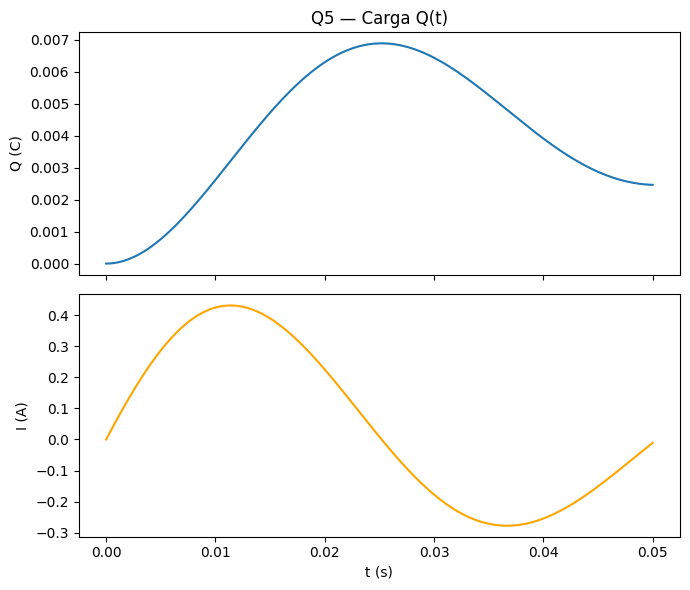

In [6]:
R0,R1,L5,C5,V05 = 500.0,250.0,15.0,4.2e-6,1000.0

def dQdt(t,Q,I): return I
def dIdt(t,Q,I): return V05/L5-(R0/L5)*I-(R1/L5)*I**3-Q/(L5*C5)

t,Q,I,step,t_end = 0.0,0.0,0.0,1e-5,0.05
ts,Qs,Is = [t],[Q],[I]
while t < t_end - 1e-12:
    k1Q=dQdt(t,Q,I); k1I=dIdt(t,Q,I)
    k2Q=dQdt(t+step/2,Q+step/2*k1Q,I+step/2*k1I)
    k2I=dIdt(t+step/2,Q+step/2*k1Q,I+step/2*k1I)
    k3Q=dQdt(t+step/2,Q+step/2*k2Q,I+step/2*k2I)
    k3I=dIdt(t+step/2,Q+step/2*k2Q,I+step/2*k2I)
    k4Q=dQdt(t+step,Q+step*k3Q,I+step*k3I)
    k4I=dIdt(t+step,Q+step*k3Q,I+step*k3I)
    Q+=step*(k1Q+2*k2Q+2*k3Q+k4Q)/6
    I+=step*(k1I+2*k2I+2*k3I+k4I)/6
    t+=step; ts.append(t); Qs.append(Q); Is.append(I)

ts,Qs,Is = np.array(ts),np.array(Qs),np.array(Is)
print(f"Q_max={Qs.max():.4e} C  I_max={Is.max():.4f} A")
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(7,6),sharex=True)
ax1.plot(ts,Qs); ax1.set_ylabel('Q (C)'); ax1.set_title('Q5 — Carga Q(t)')
ax2.plot(ts,Is,color='orange'); ax2.set_ylabel('I (A)'); ax2.set_xlabel('t (s)')
plt.tight_layout(); plt.show()


## Questão 6
Massa-mola forçado — EDO 2ª ordem, RK4, t∈[0,10] s.

ωₙ=20.00 rad/s   x_max=0.1003 m


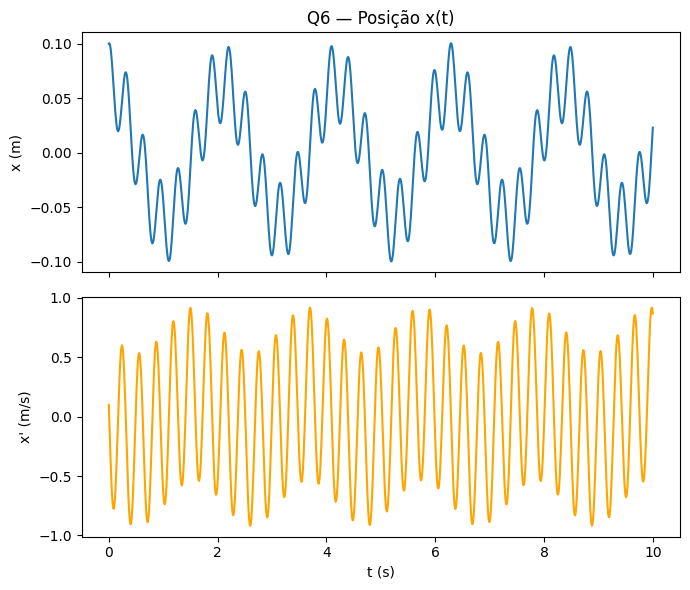

In [7]:
m,k6,F0,om = 2.0,800.0,50.0,3.0

def dxdt(t,x,v): return v
def dvdt(t,x,v): return -k6/m*x + F0/m*np.cos(om*t)

t,x,v,step,t_end = 0.0,0.1,0.1,0.01,10.0
ts,xs,vs = [t],[x],[v]
while t < t_end - 1e-10:
    k1x=dxdt(t,x,v); k1v=dvdt(t,x,v)
    k2x=dxdt(t+step/2,x+step/2*k1x,v+step/2*k1v)
    k2v=dvdt(t+step/2,x+step/2*k1x,v+step/2*k1v)
    k3x=dxdt(t+step/2,x+step/2*k2x,v+step/2*k2v)
    k3v=dvdt(t+step/2,x+step/2*k2x,v+step/2*k2v)
    k4x=dxdt(t+step,x+step*k3x,v+step*k3v)
    k4v=dvdt(t+step,x+step*k3x,v+step*k3v)
    x+=step*(k1x+2*k2x+2*k3x+k4x)/6
    v+=step*(k1v+2*k2v+2*k3v+k4v)/6
    t+=step; ts.append(t); xs.append(x); vs.append(v)

ts,xs,vs = np.array(ts),np.array(xs),np.array(vs)
print(f"ωₙ={np.sqrt(k6/m):.2f} rad/s   x_max={np.abs(xs).max():.4f} m")
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(7,6),sharex=True)
ax1.plot(ts,xs); ax1.set_ylabel('x (m)'); ax1.set_title("Q6 — Posição x(t)")
ax2.plot(ts,vs,color='orange'); ax2.set_ylabel("x' (m/s)"); ax2.set_xlabel('t (s)')
plt.tight_layout(); plt.show()
